In [1]:
SPLIT_RATIO = "70_15_15"
SPLIT_NAME = "train"
CATEGORY = "pill"
DEFECT_TYPE = "color"

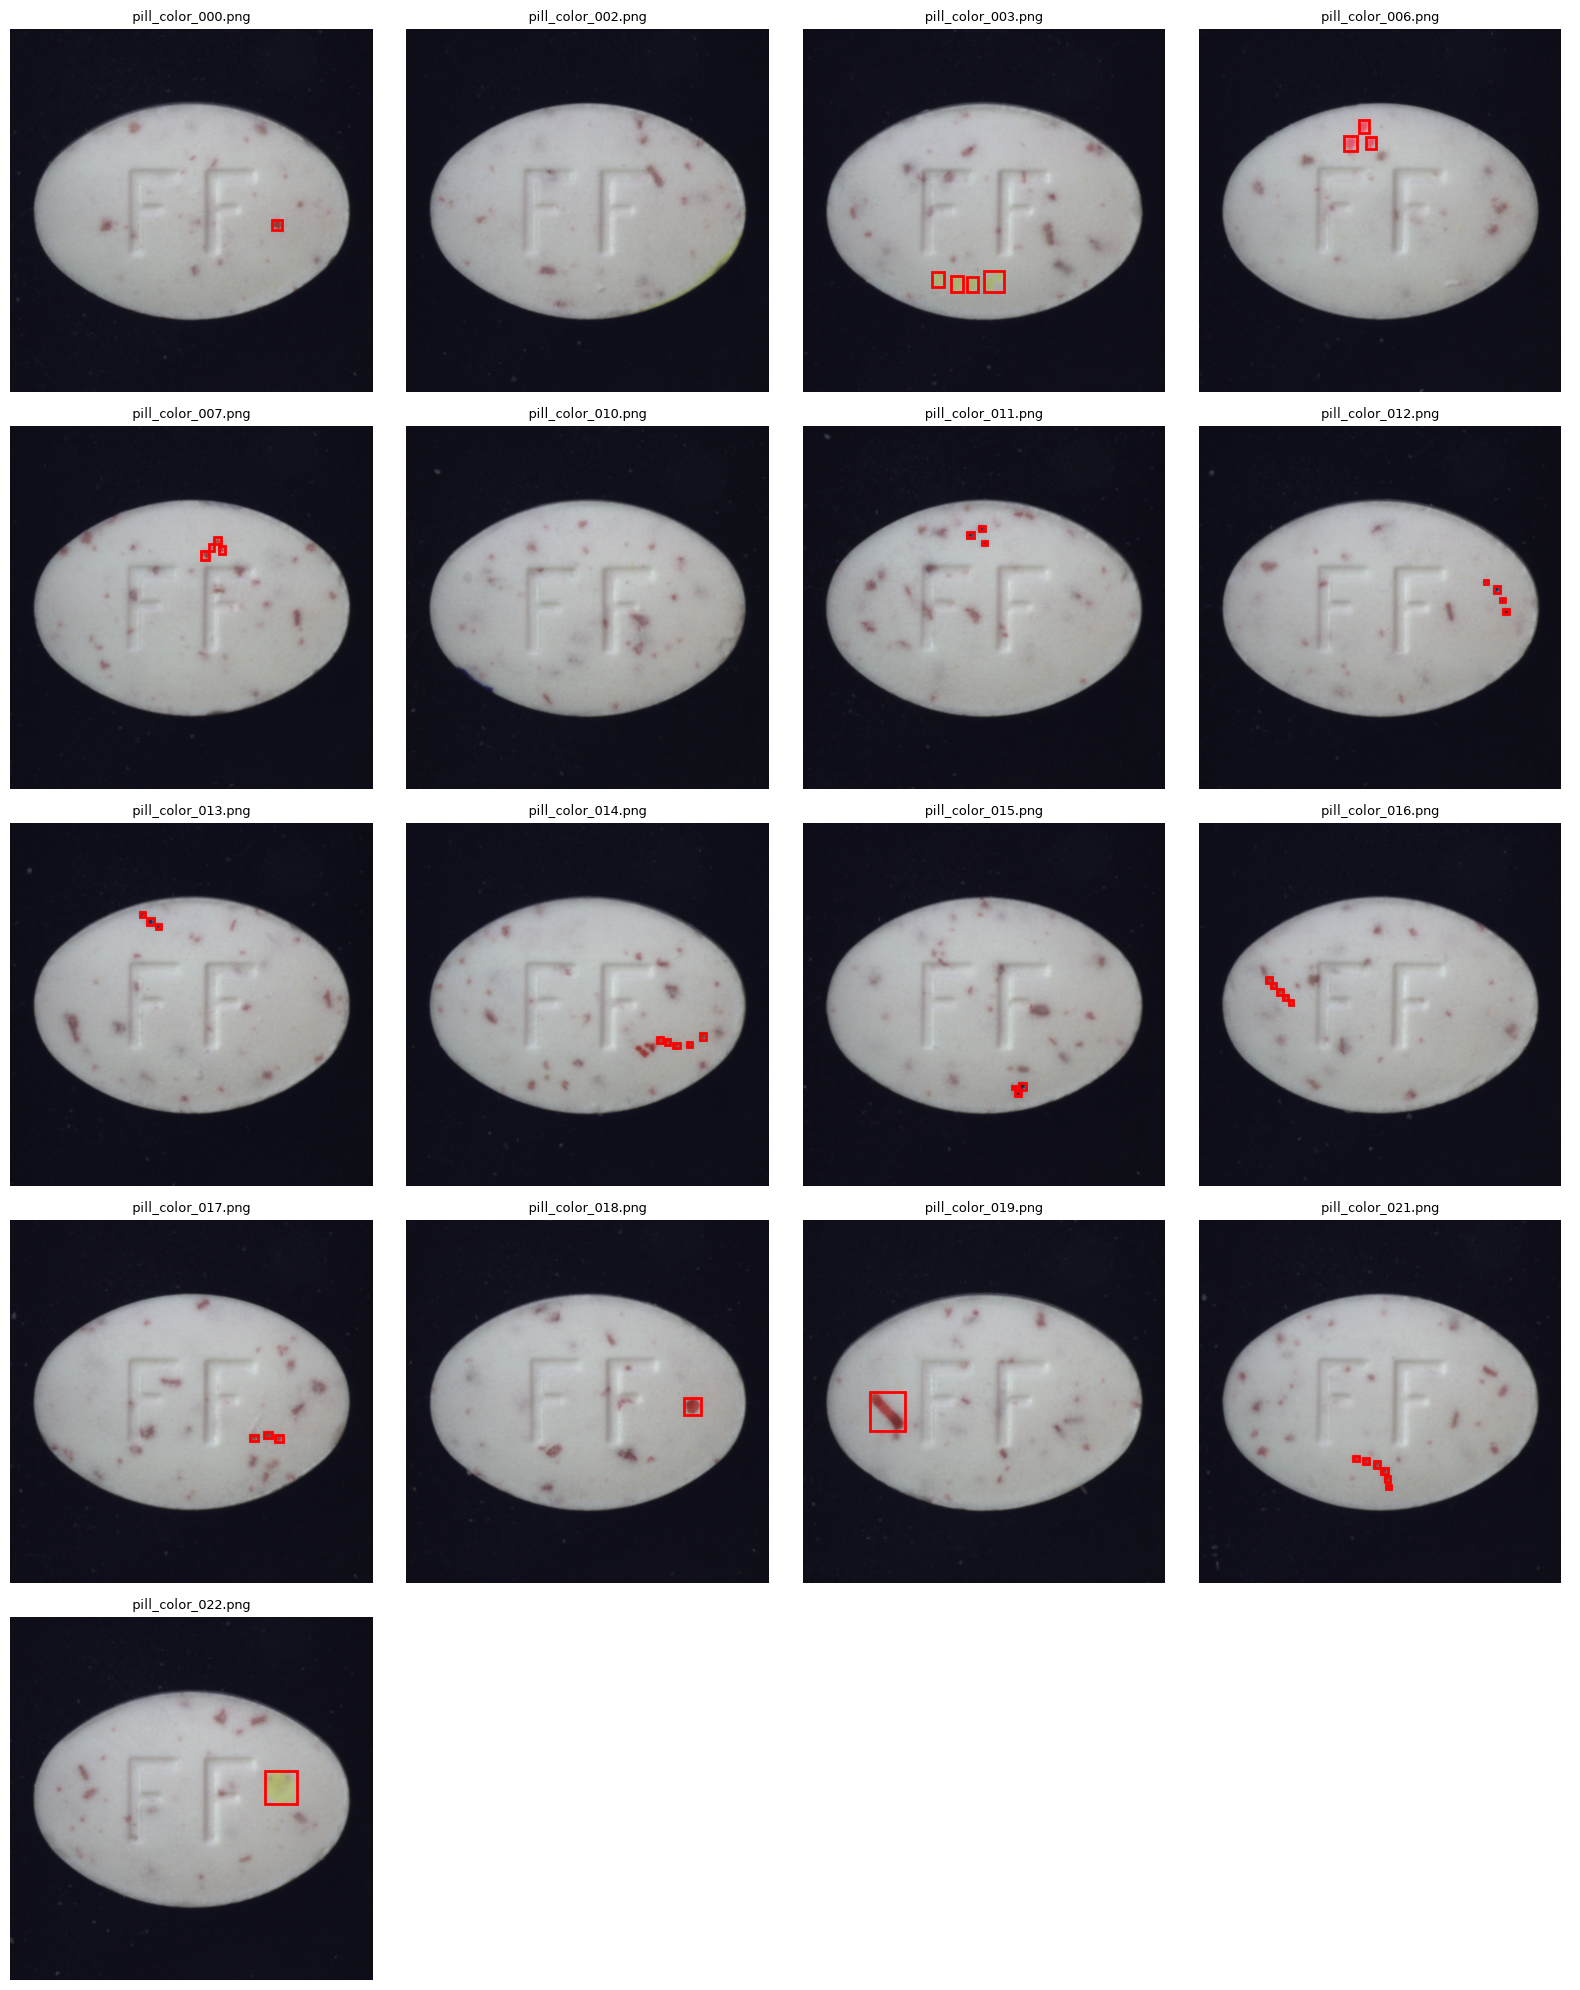

: 

In [ ]:
import os
import math
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

data_dir = Path("../data") if Path("../data").exists() else Path("data")
img_dir = data_dir / "processed" / f"split_{SPLIT_RATIO}" / "images" / SPLIT_NAME
lbl_dir = data_dir / "processed" / f"split_{SPLIT_RATIO}" / "labels" / SPLIT_NAME

prefix = f"{CATEGORY}_{DEFECT_TYPE}"
files = sorted([f for f in os.listdir(img_dir) if f.startswith(prefix) and f.endswith((".png", ".jpg"))])

if not files:
    print(f"Không tìm thấy ảnh: {prefix}")
else:
    cols = min(4, len(files))
    rows = math.ceil(len(files) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for i, fname in enumerate(files):
        ax = axes[i]
        img = cv2.cvtColor(cv2.imread(str(img_dir / fname)), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        ax.imshow(img)

        lbl_file = lbl_dir / f"{Path(fname).stem}.txt"
        if lbl_file.exists():
            with open(lbl_file, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        _, cx, cy, bw, bh = map(float, parts[:5])
                        x1 = (cx - bw / 2) * w
                        y1 = (cy - bh / 2) * h
                        rect = patches.Rectangle(
                            (x1, y1), bw * w, bh * h, linewidth=2, edgecolor="red", facecolor="none"
                        )
                        ax.add_patch(rect)

        ax.set_title(fname, fontsize=9)
        ax.axis("off")

    for j in range(len(files), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()